In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import math
import matplotlib.pyplot as plt

In [ ]:
# Any INR model just uses this format and can be plugged in without changing the Hypernet
class INRBase(nn.Module):
    def get_parameter_shapes(self):
        """
        Return dict like:
        {
            "w0": (64, 2),
            "b0": (64,),
            ...
        }
        """
        # This returned the parameters in a dictionary format
        raise NotImplementedError

    def forward_with_params(self, coords, params):
        """
        coords: [B, N, input_dim]
        params: dict of generated tensors
        returns: [B, N, output_dim]
        """
        # Show how the model return rgb colors
        raise NotImplementedError

In [ ]:
# Base siren model used for original training
class SIRENINR(INRBase):
    def __init__(self, in_features=2, hidden_features=64, hidden_layers=2, out_features=3,
                 first_omega_0=30.0, hidden_omega_0=30.0):
        super().__init__()
        self.in_features = in_features
        self.hidden_features = hidden_features
        self.hidden_layers = hidden_layers
        self.out_features = out_features
        self.first_omega_0 = first_omega_0
        self.hidden_omega_0 = hidden_omega_0

    def get_parameter_shapes(self):
        shapes = {}
        shapes["w0"] = (self.hidden_features, self.in_features)
        shapes["b0"] = (self.hidden_features,)

        for i in range(1, self.hidden_layers + 1):
            shapes[f"w{i}"] = (self.hidden_features, self.hidden_features)
            shapes[f"b{i}"] = (self.hidden_features,)

        last_idx = self.hidden_layers + 1
        shapes[f"w{last_idx}"] = (self.out_features, self.hidden_features)
        shapes[f"b{last_idx}"] = (self.out_features,)
        return shapes

    def forward_with_params(self, coords, params):
        x = torch.einsum("bni,boi->bno", coords, params["w0"]) + params["b0"].unsqueeze(1)
        x = torch.sin(self.first_omega_0 * x)

        for i in range(1, self.hidden_layers + 1):
            x = torch.einsum("bni,boi->bno", x, params[f"w{i}"]) + params[f"b{i}"].unsqueeze(1)
            x = torch.sin(self.hidden_omega_0 * x)

        last_idx = self.hidden_layers + 1
        rgb = torch.einsum("bni,boi->bno", x, params[f"w{last_idx}"]) + params[f"b{last_idx}"].unsqueeze(1)
        return rgb

In [ ]:
# More advance siren that chatgpt created and has not been trained yet
class AdvancedSIRENINR(INRBase):
    def __init__(
        self,
        in_features=2,
        hidden_features=512,
        out_features=3,
        first_omega_0=30.0,
        hidden_omega_0=30.0
    ):
        super().__init__()
        self.in_features = in_features
        self.hidden_features = hidden_features
        self.out_features = out_features
        self.first_omega_0 = first_omega_0
        self.hidden_omega_0 = hidden_omega_0

    def get_parameter_shapes(self):
        shapes = {}

        # layer1: in_features -> hidden
        shapes["w0"] = (self.hidden_features, self.in_features)
        shapes["b0"] = (self.hidden_features,)

        # layer2: hidden -> hidden
        shapes["w1"] = (self.hidden_features, self.hidden_features)
        shapes["b1"] = (self.hidden_features,)

        # layer3: hidden -> hidden
        shapes["w2"] = (self.hidden_features, self.hidden_features)
        shapes["b2"] = (self.hidden_features,)

        # layer4: (hidden + original_coords) -> hidden
        shapes["w3"] = (self.hidden_features, self.hidden_features + self.in_features)
        shapes["b3"] = (self.hidden_features,)

        # layer5: hidden -> hidden
        shapes["w4"] = (self.hidden_features, self.hidden_features)
        shapes["b4"] = (self.hidden_features,)

        # layer6: hidden -> hidden
        shapes["w5"] = (self.hidden_features, self.hidden_features)
        shapes["b5"] = (self.hidden_features,)

        # final linear: hidden -> RGB
        shapes["w6"] = (self.out_features, self.hidden_features)
        shapes["b6"] = (self.out_features,)

        return shapes

    def forward_with_params(self, coords, params):
        """
        coords: [B, N, in_features]
        params: dict of generated weights/biases
        returns: [B, N, out_features]
        """
        original_coords = coords

        x = torch.einsum("bni,boi->bno", coords, params["w0"]) + params["b0"].unsqueeze(1)
        x = torch.sin(self.first_omega_0 * x)

        x = torch.einsum("bni,boi->bno", x, params["w1"]) + params["b1"].unsqueeze(1)
        x = torch.sin(self.hidden_omega_0 * x)

        x = torch.einsum("bni,boi->bno", x, params["w2"]) + params["b2"].unsqueeze(1)
        x = torch.sin(self.hidden_omega_0 * x)

        # skip connection: concatenate original coords
        x = torch.cat([x, original_coords], dim=-1)

        x = torch.einsum("bni,boi->bno", x, params["w3"]) + params["b3"].unsqueeze(1)
        x = torch.sin(self.hidden_omega_0 * x)

        x = torch.einsum("bni,boi->bno", x, params["w4"]) + params["b4"].unsqueeze(1)
        x = torch.sin(self.hidden_omega_0 * x)

        x = torch.einsum("bni,boi->bno", x, params["w5"]) + params["b5"].unsqueeze(1)
        x = torch.sin(self.hidden_omega_0 * x)

        rgb = torch.einsum("bni,boi->bno", x, params["w6"]) + params["b6"].unsqueeze(1)
        return rgb

In [ ]:
import torch
import torch.nn as nn

# The modules used to create the hypernetwork
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_se=True, norm_type="group"):
        super().__init__()

        def make_norm(channels):
            if norm_type == "batch":
                return nn.BatchNorm2d(channels)
            elif norm_type == "group":
                groups = min(8, channels)
                while channels % groups != 0:
                    groups -= 1
                return nn.GroupNorm(groups, channels)
            else:
                raise ValueError("norm_type must be 'batch' or 'group'")

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.norm1 = make_norm(out_channels)
        self.act = nn.GELU()

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.norm2 = make_norm(out_channels)

        self.se = SEBlock(out_channels) if use_se else nn.Identity()

        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                make_norm(out_channels)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)

        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.norm2(out)
        out = self.se(out)

        out = out + identity
        out = self.act(out)
        return out


class MultiScaleAdvancedImageEncoder(nn.Module):
    def __init__(self, image_channels=3, latent_dim=256, norm_type="group"):
        super().__init__()

        def make_norm(channels):
            if norm_type == "batch":
                return nn.BatchNorm2d(channels)
            elif norm_type == "group":
                groups = min(8, channels)
                while channels % groups != 0:
                    groups -= 1
                return nn.GroupNorm(groups, channels)
            else:
                raise ValueError("norm_type must be 'batch' or 'group'")

        self.stem = nn.Sequential(
            nn.Conv2d(image_channels, 64, kernel_size=3, stride=1, padding=1, bias=False),
            make_norm(64),
            nn.GELU()
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1, use_se=True, norm_type=norm_type),
            ResidualBlock(64, 64, stride=1, use_se=True, norm_type=norm_type),
        )

        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, use_se=True, norm_type=norm_type),   # 32 -> 16
            ResidualBlock(128, 128, stride=1, use_se=True, norm_type=norm_type),
        )

        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, use_se=True, norm_type=norm_type),  # 16 -> 8
            ResidualBlock(256, 256, stride=1, use_se=True, norm_type=norm_type),
        )

        self.stage4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2, use_se=True, norm_type=norm_type),  # 8 -> 4
            ResidualBlock(512, 512, stride=1, use_se=True, norm_type=norm_type),
        )

        # pool features from multiple stages
        self.pool1 = nn.AdaptiveAvgPool2d((1, 1))
        self.pool2 = nn.AdaptiveAvgPool2d((1, 1))
        self.pool3 = nn.AdaptiveAvgPool2d((1, 1))
        self.pool4 = nn.AdaptiveAvgPool2d((1, 1))

        fused_dim = 64 + 128 + 256 + 512

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 1024),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(512, latent_dim)
        )

    def forward(self, x):
        x = self.stem(x)

        f1 = self.stage1(x)   # [B, 64, 32, 32]
        f2 = self.stage2(f1)  # [B, 128, 16, 16]
        f3 = self.stage3(f2)  # [B, 256, 8, 8]
        f4 = self.stage4(f3)  # [B, 512, 4, 4]

        p1 = self.pool1(f1).flatten(1)   # [B, 64]
        p2 = self.pool2(f2).flatten(1)   # [B, 128]
        p3 = self.pool3(f3).flatten(1)   # [B, 256]
        p4 = self.pool4(f4).flatten(1)   # [B, 512]

        fused = torch.cat([p1, p2, p3, p4], dim=1)  # [B, 960]
        z = self.head(fused)
        return z

In [ ]:
# The hypernetwork module
class HyperNetwork(nn.Module):
    def __init__(self, inr_model, image_channels=3, latent_dim=256):
        super().__init__()
        self.inr_model = inr_model
        self.latent_dim = latent_dim
        self.param_shapes = inr_model.get_parameter_shapes()

        self.encoder = MultiScaleAdvancedImageEncoder(
            image_channels=image_channels,
            latent_dim=latent_dim,
            norm_type="group"
        )

        self.param_heads = nn.ModuleDict()
        for name, shape in self.param_shapes.items():
            num_params = 1
            for dim in shape:
                num_params *= dim
            self.param_heads[name] = nn.Linear(latent_dim, num_params)

    def forward(self, image):
        z = self.encoder(image)
        B = image.shape[0]

        params = {}
        for name, shape in self.param_shapes.items():
            flat = self.param_heads[name](z)
            params[name] = flat.view(B, *shape)

        return params

In [ ]:
# Created the grid based on image shape
def make_coord_grid(height, width, device):
    ys = torch.linspace(-1.0, 1.0, steps=height, device=device)
    xs = torch.linspace(-1.0, 1.0, steps=width, device=device)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([xx, yy], dim=-1)   # [H, W, 2]
    coords = coords.view(-1, 2)              # [H*W, 2]
    return coords

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

make_coord_grid(4,4,device)

tensor([[-1.0000, -1.0000],
        [-0.3333, -1.0000],
        [ 0.3333, -1.0000],
        [ 1.0000, -1.0000],
        [-1.0000, -0.3333],
        [-0.3333, -0.3333],
        [ 0.3333, -0.3333],
        [ 1.0000, -0.3333],
        [-1.0000,  0.3333],
        [-0.3333,  0.3333],
        [ 0.3333,  0.3333],
        [ 1.0000,  0.3333],
        [-1.0000,  1.0000],
        [-0.3333,  1.0000],
        [ 0.3333,  1.0000],
        [ 1.0000,  1.0000]], device='cuda:0')

In [54]:
import math
import torch
import matplotlib.pyplot as plt

def compute_psnr(preds, targets):
    mse = torch.mean((preds - targets) ** 2)
    if mse.item() == 0:
        return float("inf")
    return (10 * torch.log10(1.0 / mse)).item()


def reconstruct_batch(hypernet, inr_model, images, device):
    hypernet.eval()

    with torch.no_grad():
        images = images.to(device)   # [B, 3, H, W]
        B, C, H, W = images.shape

        coords = make_coord_grid(H, W, device)              # [H*W, 2]
        coords = coords.unsqueeze(0).expand(B, -1, -1)      # [B, H*W, 2]

        targets = images.permute(0, 2, 3, 1).reshape(B, H * W, 3)   # [B, H*W, 3]

        params = hypernet(images)
        preds = inr_model.forward_with_params(coords, params)        # [B, H*W, 3]
        preds = preds.clamp(0.0, 1.0)

        recon_images = preds.view(B, H, W, 3).permute(0, 3, 1, 2)   # [B, 3, H, W]

        mse = torch.mean((preds - targets) ** 2).item()
        psnr = compute_psnr(preds, targets)

    return recon_images.cpu(), images.cpu(), mse, psnr


def show_reconstructions(hypernet, inr_model, loader, class_names=None, device="cuda", num_images=5):
    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]

    recon_images, orig_images, mse, psnr = reconstruct_batch(
        hypernet, inr_model, images, device
    )

    print(f"MSE:  {mse:.6f}")
    print(f"PSNR: {psnr:.2f} dB")

    plt.figure(figsize=(8, 3 * num_images))

    for i in range(num_images):
        # Original
        plt.subplot(num_images, 2, 2 * i + 1)
        orig = orig_images[i].permute(1, 2, 0).numpy()
        plt.imshow(orig)
        if class_names is not None:
            plt.title(f"Original: {class_names[labels[i].item()]}")
        else:
            plt.title("Original")
        plt.axis("off")

        # Reconstruction
        plt.subplot(num_images, 2, 2 * i + 2)
        recon = recon_images[i].permute(1, 2, 0).numpy()
        plt.imshow(recon)
        plt.title("Reconstruction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [55]:
def train_hypernetwork(hypernet, inr_model, train_loader, device, num_epochs=5):
    hypernet = hypernet.to(device)
    optimizer = optim.Adam(hypernet.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(num_epochs):
        hypernet.train()
        running_loss = 0.0

        for images, _ in train_loader:
            images = images.to(device)
            B, C, H, W = images.shape

            coords = make_coord_grid(H, W, device).unsqueeze(0).expand(B, -1, -1)
            targets = images.permute(0, 2, 3, 1).reshape(B, H * W, 3)

            optimizer.zero_grad()

            params = hypernet(images)
            preds = inr_model.forward_with_params(coords, params)

            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}: {running_loss / len(train_loader):.6f}")

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Data
# -------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True
)



Using device: cuda


In [89]:
inr_model = SIRENINR(in_features=2, hidden_features=32, hidden_layers=2, out_features=3)

# inr_model = AdvancedSIRENINR(
#     in_features=2,
#     hidden_features=128,   # start smaller than 512 for hypernet training
#     out_features=3,
#     first_omega_0=30.0,
#     hidden_omega_0=30.0
# )

In [ ]:
hypernet = HyperNetwork(inr_model=inr_model, latent_dim=128)
train_hypernetwork(hypernet, inr_model, train_loader, device, 50)

Epoch 1: 0.095915
Epoch 2: 0.058471


MSE:  0.009116
PSNR: 20.40 dB


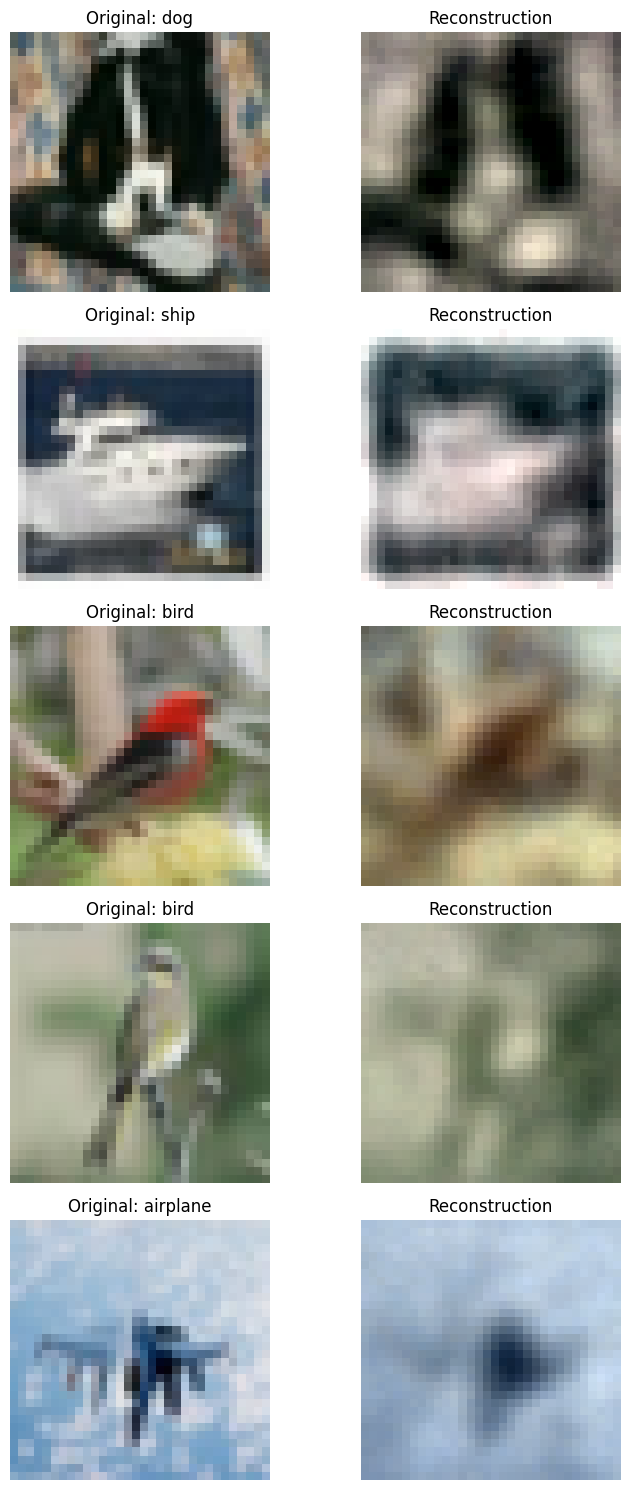

In [87]:
show_reconstructions(
    hypernet,
    inr_model,
    test_loader,
    class_names=test_dataset.classes,
    device=device,
    num_images=5
)

MSE:  0.008079
PSNR: 20.93 dB


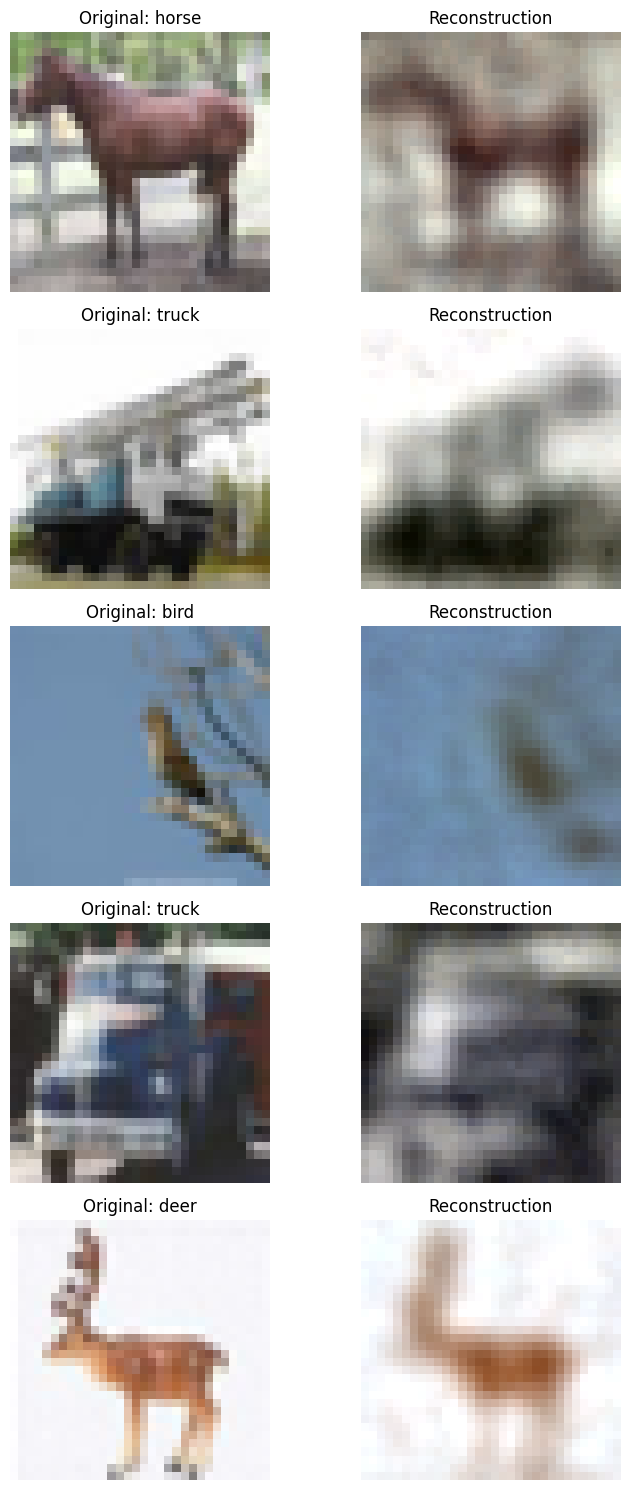

In [88]:
show_reconstructions(
    hypernet,
    inr_model,
    train_loader,
    class_names=train_dataset.classes,
    device=device,
    num_images=5
)